# Study B Preparation (AL-Only)

This notebook is preparation-only. It does **not** run the full Study B sensitivity analysis unless `signal.dat` interpretation is sufficiently verified.

Scope in this notebook:

- input loading
- metadata and interpretation checks
- signal file inspection
- reusable AL noise PSD preprocessing
- signal/noise grid alignment diagnostics
- Study B readiness decision


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


## Section 1 — Input Loading

Load `signal.dat` and AL noise files. Reuse the validated AL interpretation from Study A: AL noise second columns are treated as ASD and converted to PSD by squaring.


In [2]:
base_dir_candidates = [Path("Al2O3_Al_athermal"), Path("wk6/Al2O3_Al_athermal")]
base_dir = next((p for p in base_dir_candidates if p.exists()), None)
if base_dir is None:
    raise FileNotFoundError("Could not locate wk6/Al2O3_Al_athermal from current working directory.")

signal_path = base_dir / "signal.dat"
noise_paths = {
    "total": base_dir / "total_noise.dat",
    "squid": base_dir / "SQUID_noise.dat",
    "johnson": base_dir / "Johnson_noise.dat",
    "td": base_dir / "TD_noise.dat",
    "er": base_dir / "Er_noise.dat",
}

signal_data = np.loadtxt(signal_path)
noise_data = {k: np.loadtxt(v) for k, v in noise_paths.items()}

print(f"Loaded signal: {signal_path}")
for key, path in noise_paths.items():
    print(f"Loaded noise ({key}): {path}")

print("\nArray shapes:")
print("signal_data:", signal_data.shape)
for key, arr in noise_data.items():
    print(f"noise_data[{key!r}]: {arr.shape}")


Loaded signal: Al2O3_Al_athermal/signal.dat
Loaded noise (total): Al2O3_Al_athermal/total_noise.dat
Loaded noise (squid): Al2O3_Al_athermal/SQUID_noise.dat
Loaded noise (johnson): Al2O3_Al_athermal/Johnson_noise.dat
Loaded noise (td): Al2O3_Al_athermal/TD_noise.dat
Loaded noise (er): Al2O3_Al_athermal/Er_noise.dat

Array shapes:
signal_data: (16384, 2)
noise_data['total']: (16384, 2)
noise_data['squid']: (16384, 2)
noise_data['johnson']: (16384, 2)
noise_data['td']: (16384, 2)
noise_data['er']: (16384, 2)


## Section 2 — Metadata and Interpretation Checks

This section records unresolved interpretation questions for `signal.dat`:

- What does `signal.dat` represent?
- Is it frequency-domain or time-domain?
- Is it a pulse template, transfer function, responsivity, or only a relative shape?
- Is it calibrated to deposited energy or still in readout units?
- Is it one-sided or two-sided?

No silent guessing is allowed. If the meaning is not provable from file content, it is marked as unresolved.


In [3]:
# Preparation-stage interpretation registry for signal.dat.
# These fields are intentionally conservative unless independently verified upstream.
signal_interpretation_status = {
    "representation": "unresolved",
    "domain": "unresolved",
    "object_type": "unresolved",
    "calibration_state": "unresolved",
    "sidedness": "unresolved",
    "evidence_from_content_only": "insufficient for definitive physical interpretation",
}

# Optional weak structural hints (not treated as proof):
if signal_data.ndim == 2 and signal_data.shape[1] >= 2:
    candidate_axis = signal_data[:, 0]
    axis_monotonic = bool(np.all(np.diff(candidate_axis) >= 0))
    signal_interpretation_status["structural_hint"] = (
        "two-column table with monotonic first column" if axis_monotonic else "two-column table with non-monotonic first column"
    )
else:
    signal_interpretation_status["structural_hint"] = "not a clear two-column axis/value table"

status_df = pd.DataFrame(
    [{"item": k, "status": v} for k, v in signal_interpretation_status.items()],
    columns=["item", "status"],
)
print("signal.dat interpretation status (preparation stage):")
print(status_df.to_string(index=False))
display(status_df)


signal.dat interpretation status (preparation stage):
                      item                                              status
            representation                                          unresolved
                    domain                                          unresolved
               object_type                                          unresolved
         calibration_state                                          unresolved
                 sidedness                                          unresolved
evidence_from_content_only insufficient for definitive physical interpretation
           structural_hint        two-column table with monotonic first column


,item,status
0,representation,unresolved
1,domain,unresolved
2,object_type,unresolved
3,calibration_state,unresolved
4,sidedness,unresolved
5,evidence_from_content_only,insufficient for definitive physical interpret...
6,structural_hint,two-column table with monotonic first column


## Section 3 — Signal File Inspection

Inspect `signal.dat` numerically and plot it on its native grid. If interpretation remains unresolved, use neutral axis labels.


signal.dat inspection:
- ndim: 2
- shape: (16384, 2)
- finite entries: True
signal native axis: n=16384, min=1, max=3e+07, monotonic_non_decreasing=True, monotonic_strict=True
signal native axis step stats: min=0.00105144, median=5.75595, max=31510.1
signal values finite: True
signal values strictly positive: True
signal values has negatives: False
signal grid matches AL noise grid exactly: True


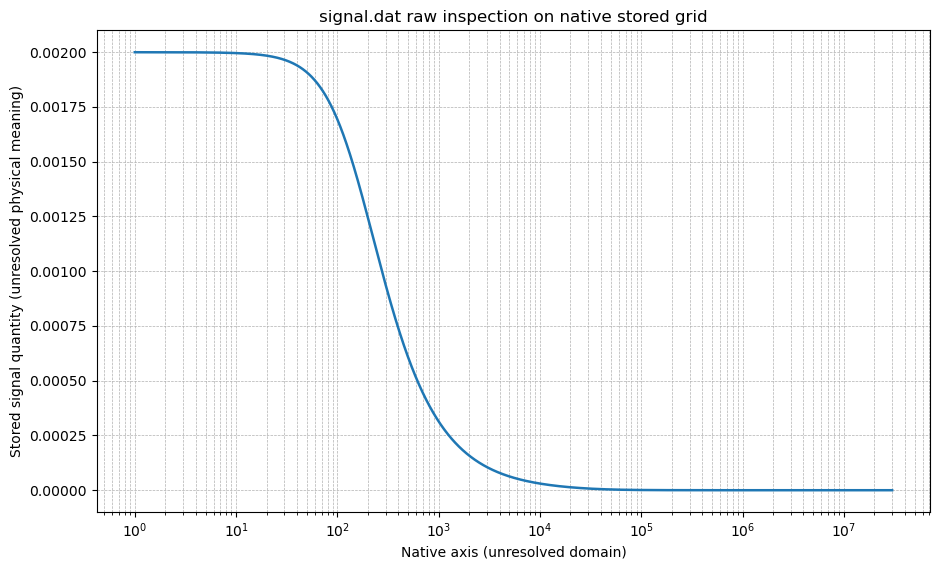

In [4]:
def summarize_axis(name, axis):
    diffs = np.diff(axis)
    monotonic_non_decreasing = bool(np.all(diffs >= 0))
    monotonic_strict = bool(np.all(diffs > 0))
    print(
        f"{name}: n={axis.size}, min={np.nanmin(axis):.6g}, max={np.nanmax(axis):.6g}, "
        f"monotonic_non_decreasing={monotonic_non_decreasing}, monotonic_strict={monotonic_strict}"
    )
    if diffs.size:
        print(
            f"{name} step stats: min={np.nanmin(diffs):.6g}, median={np.nanmedian(diffs):.6g}, max={np.nanmax(diffs):.6g}"
        )

print("signal.dat inspection:")
print("- ndim:", signal_data.ndim)
print("- shape:", signal_data.shape)
print("- finite entries:", bool(np.all(np.isfinite(signal_data))))

if signal_data.ndim == 1:
    signal_axis = np.arange(signal_data.size, dtype=float)
    signal_values = signal_data
    signal_has_explicit_axis = False
elif signal_data.ndim == 2 and signal_data.shape[1] >= 2:
    signal_axis = signal_data[:, 0]
    signal_values = signal_data[:, 1]
    signal_has_explicit_axis = True
else:
    raise ValueError("Unsupported signal.dat shape for preparation notebook; expected 1D or 2D with >=2 columns.")

summarize_axis("signal native axis", signal_axis)
print("signal values finite:", bool(np.all(np.isfinite(signal_values))))
print("signal values strictly positive:", bool(np.all(signal_values > 0)))
print("signal values has negatives:", bool(np.any(signal_values < 0)))

al_freq = noise_data["total"][:, 0]
grid_match = signal_has_explicit_axis and signal_axis.shape == al_freq.shape and np.allclose(signal_axis, al_freq)
print("signal grid matches AL noise grid exactly:", grid_match)

plt.figure(figsize=(9.5, 5.8))
valid = np.isfinite(signal_axis) & np.isfinite(signal_values)
if np.all(signal_axis[valid] > 0):
    plt.semilogx(signal_axis[valid], signal_values[valid], linewidth=1.8)
else:
    plt.plot(signal_axis[valid], signal_values[valid], linewidth=1.8)
plt.title("signal.dat raw inspection on native stored grid")
if signal_interpretation_status["domain"] == "unresolved":
    plt.xlabel("Native axis (unresolved domain)")
    plt.ylabel("Stored signal quantity (unresolved physical meaning)")
else:
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Signal quantity [interpreted units]")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


## Section 4 — Noise Preprocessing for Study B

Build reusable AL-grid PSD arrays from validated Study A convention:

- `psd_total`
- `psd_squid`
- `psd_johnson`
- `psd_td`
- `psd_er`


In [5]:
def require_two_column(name, arr):
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f"{name} must be a 2-column array [freq, ASD].")

for key, arr in noise_data.items():
    require_two_column(key, arr)

al_freq = noise_data["total"][:, 0]
for key, arr in noise_data.items():
    if arr.shape[0] != al_freq.shape[0] or not np.allclose(arr[:, 0], al_freq):
        raise ValueError(f"Noise file '{key}' is not on common AL frequency grid.")

asd_total = noise_data["total"][:, 1]
asd_squid = noise_data["squid"][:, 1]
asd_johnson = noise_data["johnson"][:, 1]
asd_td = noise_data["td"][:, 1]
asd_er = noise_data["er"][:, 1]

psd_total = asd_total**2
psd_squid = asd_squid**2
psd_johnson = asd_johnson**2
psd_td = asd_td**2
psd_er = asd_er**2

study_b_noise_inputs = {
    "frequency_hz": al_freq,
    "psd_total": psd_total,
    "psd_squid": psd_squid,
    "psd_johnson": psd_johnson,
    "psd_td": psd_td,
    "psd_er": psd_er,
    "noise_interpretation": "AL ASD from professor plot; PSD constructed by squaring ASD",
    "working_units": "ASD in microPhi0/sqrt(Hz) (or working-equivalent microV/sqrt(Hz)); PSD in squared units per Hz",
}

print("Prepared reusable AL noise PSD inputs for later Study B use:")
for k in ["frequency_hz", "psd_total", "psd_squid", "psd_johnson", "psd_td", "psd_er"]:
    print(f"- {k}: shape={study_b_noise_inputs[k].shape}")


Prepared reusable AL noise PSD inputs for later Study B use:
- frequency_hz: shape=(16384,)
- psd_total: shape=(16384,)
- psd_squid: shape=(16384,)
- psd_johnson: shape=(16384,)
- psd_td: shape=(16384,)
- psd_er: shape=(16384,)


## Section 5 — Grid Alignment for Possible OF Study

Prepare a common signal/noise grid diagnostic, but do not compute OF weighting yet.


In [6]:
signal_grid_available = signal_data.ndim == 2 and signal_data.shape[1] >= 2

if signal_grid_available:
    signal_freq_like = signal_data[:, 0]
    signal_quantity = signal_data[:, 1]

    same_bins = signal_freq_like.shape == al_freq.shape and np.allclose(signal_freq_like, al_freq)
    interpolation_required = not same_bins

    overlap_min = max(float(np.nanmin(signal_freq_like)), float(np.nanmin(al_freq)))
    overlap_max = min(float(np.nanmax(signal_freq_like)), float(np.nanmax(al_freq)))
    overlap_valid = overlap_max > overlap_min

    print("Signal/noise grid alignment report:")
    print(f"- grids already match: {same_bins}")
    print(f"- interpolation required: {interpolation_required}")
    if overlap_valid:
        print(f"- overlapping frequency band [Hz]: [{overlap_min:.6g}, {overlap_max:.6g}]")
    else:
        print("- overlapping frequency band [Hz]: none")

    signal_grid_alignment = {
        "grid_match": same_bins,
        "interpolation_required": interpolation_required,
        "overlap_min_hz": overlap_min if overlap_valid else np.nan,
        "overlap_max_hz": overlap_max if overlap_valid else np.nan,
    }
else:
    print("Signal/noise grid alignment report:")
    print("- signal.dat does not expose a clear frequency axis for alignment")
    print("- interpolation requirement: unresolved")
    print("- overlapping frequency band: unresolved")
    signal_grid_alignment = {
        "grid_match": False,
        "interpolation_required": "unresolved",
        "overlap_min_hz": np.nan,
        "overlap_max_hz": np.nan,
    }

print("\nOF weighting intentionally not computed in this preparation notebook.")


Signal/noise grid alignment report:
- grids already match: True
- interpolation required: False
- overlapping frequency band [Hz]: [1, 3e+07]

OF weighting intentionally not computed in this preparation notebook.


## Section 6 — Study B Readiness Decision

Decision checklist for whether full Study B can start immediately.


In [7]:
signal_meaning_clear_enough = all(
    signal_interpretation_status[k] != "unresolved"
    for k in ["representation", "domain", "object_type", "calibration_state", "sidedness"]
)

if signal_meaning_clear_enough:
    of_ratio_ready = True
    absolute_baseline_possible = signal_interpretation_status["calibration_state"] != "unresolved"
else:
    of_ratio_ready = False
    absolute_baseline_possible = False

study_b_ready = bool(signal_meaning_clear_enough and signal_grid_alignment.get("grid_match", False))

checklist_rows = [
    {
        "question": "Is signal.dat meaning clear enough to compute |S(f)|^2 / P_tot(f)?",
        "status": "yes" if of_ratio_ready else "no",
    },
    {
        "question": "Can baseline sensitivity be interpreted absolutely?",
        "status": "yes" if absolute_baseline_possible else "no (currently relative or unresolved)",
    },
    {
        "question": "Ready for full Study B now?",
        "status": "yes" if study_b_ready else "no (signal metadata clarification still required)",
    },
]

checklist_df = pd.DataFrame(checklist_rows, columns=["question", "status"])
print("Study B readiness checklist:")
print(checklist_df.to_string(index=False))
display(checklist_df)

decision_lines = [
    "### Study B Preparation Decision",
    f"- signal.dat interpretation status: {'resolved' if signal_meaning_clear_enough else 'unresolved'}",
    f"- grid alignment status: {'matched' if signal_grid_alignment.get('grid_match', False) else 'not matched or unresolved'}",
    f"- full Study B readiness: {'READY' if study_b_ready else 'NOT READY'}",
]

display(Markdown("\n".join(decision_lines)))


Study B readiness checklist:
                                                          question                                            status
Is signal.dat meaning clear enough to compute |S(f)|^2 / P_tot(f)?                                                no
               Can baseline sensitivity be interpreted absolutely?             no (currently relative or unresolved)
                                       Ready for full Study B now? no (signal metadata clarification still required)


,question,status
0,Is signal.dat meaning clear enough to compute ...,no
1,Can baseline sensitivity be interpreted absolu...,no (currently relative or unresolved)
2,Ready for full Study B now?,no (signal metadata clarification still required)


### Study B Preparation Decision
- signal.dat interpretation status: unresolved
- grid alignment status: matched
- full Study B readiness: NOT READY